In [1]:
import sys

sys.path.append("../../")
from NB_config import *

from collections import Counter
from wordcloud import WordCloud

In [2]:
df = pd.read_csv(DATASET_PATH, usecols=CATEGORY_COLS, low_memory=False)

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Shape: 149,485 rows × 8 columns


,business_id,name,stars,categories,attributes,price_level,description,entity_type
0,680ac5b42a0f865f,Trèsind Studio,5.0,restaurant;indian,NaN,4.0,NaN,restaurant
1,fb5f7e0a9343ae29,Atrevo,4.0,restaurant;contemporary,NaN,2.0,NaN,restaurant
2,2ca10f4418f15849,Chocho,4.0,"restaurant;creative, modern cuisine",NaN,3.0,NaN,restaurant


In [3]:
print("=== categories sample ===")
print(df["categories"].dropna().iloc[:5].tolist())

print("\n=== attributes sample ===")
print(df["attributes"].dropna().iloc[:5].tolist())

print("\n=== attributes dtype ===", df["attributes"].dtype)
print("=== null counts ===")
print(df[["categories", "attributes", "description"]].isnull().sum())

=== categories sample ===
['restaurant;indian', 'restaurant;contemporary', 'restaurant;creative, modern cuisine', 'restaurant;modern cuisine', 'restaurant;modern cuisine']

=== attributes sample ===
['{"wheelchair": "no"}', '{"wheelchair": "yes"}', '{"wheelchair": "yes"}', '{"wheelchair": "yes"}', '{"wheelchair": "no"}']

=== attributes dtype === str
=== null counts ===
categories          0
attributes     145734
description     30080
dtype: int64


In [6]:
df["categories_list"] = df["categories"].fillna("").str.split(";")
df["categories_list"] = df["categories_list"].apply(
    lambda x: [c.strip() for c in x if c.strip() != ""]
)

# Explode so each category gets its own row
df_cats = df.explode("categories_list").rename(columns={"categories_list": "category"})
df_cats = df_cats[df_cats["category"].notna() & (df_cats["category"] != "")]

print(f"Unique categories: {df_cats['category'].nunique():,}")
df_cats[["name", "entity_type", "category", "stars"]].head(5)

Unique categories: 1,676


,name,entity_type,category,stars
0,Trèsind Studio,restaurant,restaurant,5.0
0,Trèsind Studio,restaurant,indian,5.0
1,Atrevo,restaurant,restaurant,4.0
1,Atrevo,restaurant,contemporary,4.0
2,Chocho,restaurant,restaurant,4.0


In [ ]:
def parse_attributes(val):
    if pd.isna(val) or val == "":
        return {}
    try:
        return json.loads(val)
    except (json.JSONDecodeError, TypeError):
        return {}


df["attributes_dict"] = df["attributes"].apply(parse_attributes)

attrs_flat = pd.json_normalize(df["attributes_dict"])
attrs_flat.index = df.index

print(f"Attribute keys found: {attrs_flat.shape[1]}")
print(f"Columns: {attrs_flat.columns.tolist()}")
print(f"\nWheelchair coverage: {attrs_flat['wheelchair'].notna().sum():,} rows")
print(attrs_flat["wheelchair"].value_counts())

Attribute keys found: 11
Columns: ['wheelchair', 'fee', 'internet_access', 'smoking', 'air_conditioning', 'takeaway', 'capacity', 'delivery', 'outdoor_seating', 'diet_vegetarian', 'diet_vegan']

Wheelchair coverage: 2,127 rows
wheelchair
yes        995
no         643
limited    489
Name: count, dtype: int64


In [9]:
top_cats = df_cats["category"].value_counts().head(10)

fig = px.bar(
    x=top_cats.values,
    y=top_cats.index,
    orientation="h",
    title="Top 10 Categories (All Entities)",
    labels={"x": "Count", "y": "Category"},
    template=PLOTLY_TEMPLATE,
)
fig.update_layout(yaxis=dict(autorange="reversed"))
fig.show()

In [10]:
for entity in df_cats["entity_type"].dropna().unique():
    subset = df_cats[df_cats["entity_type"] == entity]
    top = subset["category"].value_counts().head(15)

    fig = px.bar(
        x=top.values,
        y=top.index,
        orientation="h",
        title=f"Top 15 Categories — {entity}",
        labels={"x": "Count", "y": "Category"},
        template=PLOTLY_TEMPLATE,
    )
    fig.update_layout(yaxis=dict(autorange="reversed"))
    fig.show()

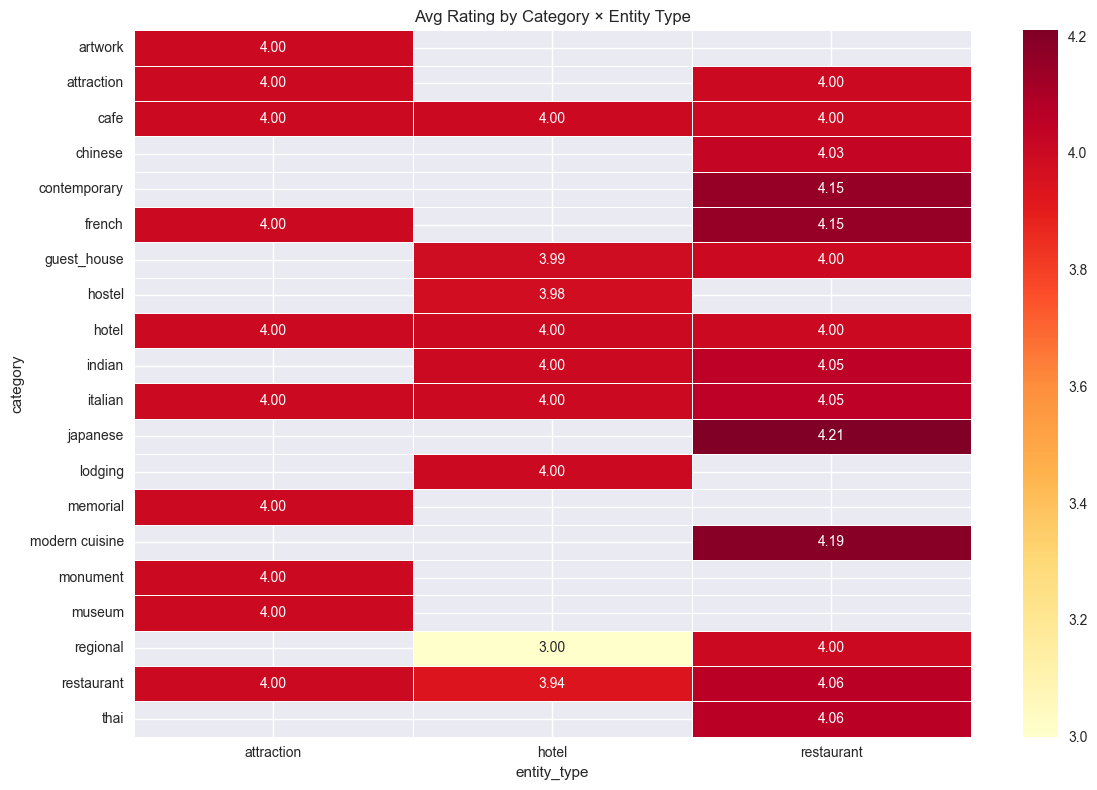

In [ ]:
top_20 = df_cats["category"].value_counts().head(20).index

heat_data = (
    df_cats[df_cats["category"].isin(top_20)]
    .groupby(["category", "entity_type"])["stars"]
    .mean()
    .unstack()
    .round(2)
)

plt.figure(figsize=(12, 8))
sns.heatmap(heat_data, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("Avg Rating by Category × Entity Type")
plt.tight_layout()
plt.show()

In [12]:
counts = df["entity_type"].value_counts()

fig = px.pie(
    values=counts.values,
    names=counts.index,
    title="Entity Type Distribution",
    template=PLOTLY_TEMPLATE,
    hole=0.35,
)
fig.show()

In [13]:
fig = px.histogram(
    df[df["price_level"].notna()],
    x="price_level",
    color="entity_type",
    barmode="group",
    title="Price Level Distribution by Entity Type",
    template=PLOTLY_TEMPLATE,
)
fig.show()

In [14]:
wheelchair_data = attrs_flat["wheelchair"].value_counts()

fig = px.pie(
    values=wheelchair_data.values,
    names=wheelchair_data.index,
    title="Wheelchair Accessibility (where reported)",
    template=PLOTLY_TEMPLATE,
    hole=0.35,
)
fig.show()

In [22]:
hotels = df[df["entity_type"] == "hotel"]

print(f"Hotels: {len(hotels):,} rows")
print(f"Avg price level : {hotels['price_level'].mean():.2f}")
print(f"Avg stars       : {hotels['stars'].mean():.2f}")

fig = px.histogram(
    hotels,
    x="stars",
    nbins=20,
    title="Hotel Star Rating Distribution",
    template=PLOTLY_TEMPLATE,
)
fig.show()

Hotels: 126,599 rows
Avg price level : nan
Avg stars       : 4.00


In [29]:
fill_candidates = {
    "price_level": "Predictable from categories + stars via regression",
    "description": "Generatable from name + categories via LLM",
    "attributes": "Partially inferable from entity_type + categories",
}

fill_candidates = {k: v for k, v in fill_candidates.items() if k in df.columns}

missing = (
    df[list(fill_candidates.keys())].isnull().sum().rename("missing_count").to_frame()
)
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(1)
missing["fill_strategy"] = missing.index.map(fill_candidates)

print(missing.to_string())

             missing_count  missing_pct                                       fill_strategy
price_level         141984         95.0  Predictable from categories + stars via regression
description          30080         20.1          Generatable from name + categories via LLM
attributes          145734         97.5   Partially inferable from entity_type + categories
